# Exponential–normal mixture examples

This notebook demonstrates the public `densmix` API for an exponential–normal
mixture. It uses:

- `simulate_exp_normal()` to generate data and return an `ExpNormalSimulation`;
- `fit_exp_normal()` to fit the model and return an `ExpNormalFit`.

The returned objects expose named attributes such as `.data`, `.parameters`,
`.converged`, `.n_iter`, `.responsibilities`, and `.log_likelihood_history`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from densmix import fit_exp_normal, simulate_exp_normal

## Generate data

We generate 200 datasets. Each dataset contains 1,000 observations, with the
mixture parameters sampled from ranges that usually keep the exponential and
normal densities well separated.

In [2]:
np.random.seed(123)

n_sim = 200
sample_size = 1_000

exp_norm_parameter_list = [
    {
        "weight": np.random.uniform(0.1, 0.9),
        "lambda": np.random.uniform(0.5, 5.0),
        "mu": np.random.uniform(7.0, 25.0),
        "sigma": np.random.uniform(1.0, 2.0),
    }
    for _ in range(n_sim)
]

exp_norm_simulations = [
    simulate_exp_normal(size=sample_size, parameters=parameters)
    for parameters in exp_norm_parameter_list
]

exp_norm_true_parameter_df = pd.DataFrame(
    [simulation.parameters for simulation in exp_norm_simulations]
)

print(f"Generated {len(exp_norm_simulations)} datasets.")
print(f"First dataset shape: {exp_norm_simulations[0].data.shape}")
exp_norm_true_parameter_df.head()

Generated 200 datasets.
First dataset shape: (1000,)


,weight,lambda,mu,sigma
0,0.657175,1.787627,11.083326,1.551315
1,0.675575,2.403979,24.653756,1.684830
2,0.484746,2.264529,13.177204,1.729050
3,0.450858,0.768551,14.164797,1.737995
4,0.245993,1.289533,16.567925,1.531828


## Fit the mixtures

Pass each simulation's `.data` attribute to `fit_exp_normal()`. The fit results
are structured objects, so values are read through attributes instead of
dictionary keys.

In [3]:
exp_norm_fits = [
    fit_exp_normal(simulation.data)
    for simulation in exp_norm_simulations
]

exp_norm_fitted_parameter_df = pd.DataFrame(
    [fit.parameters for fit in exp_norm_fits]
)

fit_diagnostics_df = pd.DataFrame(
    {
        "converged": [fit.converged for fit in exp_norm_fits],
        "n_iter": [fit.n_iter for fit in exp_norm_fits],
        "log_likelihood": [fit.log_likelihood for fit in exp_norm_fits],
    }
)

fit_diagnostics_df.head()

,converged,n_iter,log_likelihood
0,True,6,-1523.158019
1,True,5,-1276.809606
2,True,5,-1751.719745
3,True,6,-2296.968538
4,True,3,-2150.916867


## Compare one generated dataset with its fit

The simulation stores the parameters used to generate the data, while the fit
stores the estimated parameters. This table compares them for the first dataset.

In [4]:
example_index = 0
example_simulation = exp_norm_simulations[example_index]
example_fit = exp_norm_fits[example_index]

example_comparison = pd.DataFrame(
    {
        "true": example_simulation.parameters,
        "fitted": example_fit.parameters,
    }
)
example_comparison["absolute_error"] = (
    example_comparison["fitted"] - example_comparison["true"]
).abs()

print(
    f"Converged: {example_fit.converged}; "
    f"iterations: {example_fit.n_iter}; "
    f"final log likelihood: {example_fit.log_likelihood:.3f}"
)
example_comparison

Converged: True; iterations: 6; final log likelihood: -1523.158


,true,fitted,absolute_error
weight,0.657175,0.656009,0.001166
lambda,1.787627,1.788209,0.000582
mu,11.083326,11.139808,0.056481
sigma,1.551315,1.404077,0.147238


## Compare all true and fitted parameters

Points close to the diagonal have similar true and fitted values.

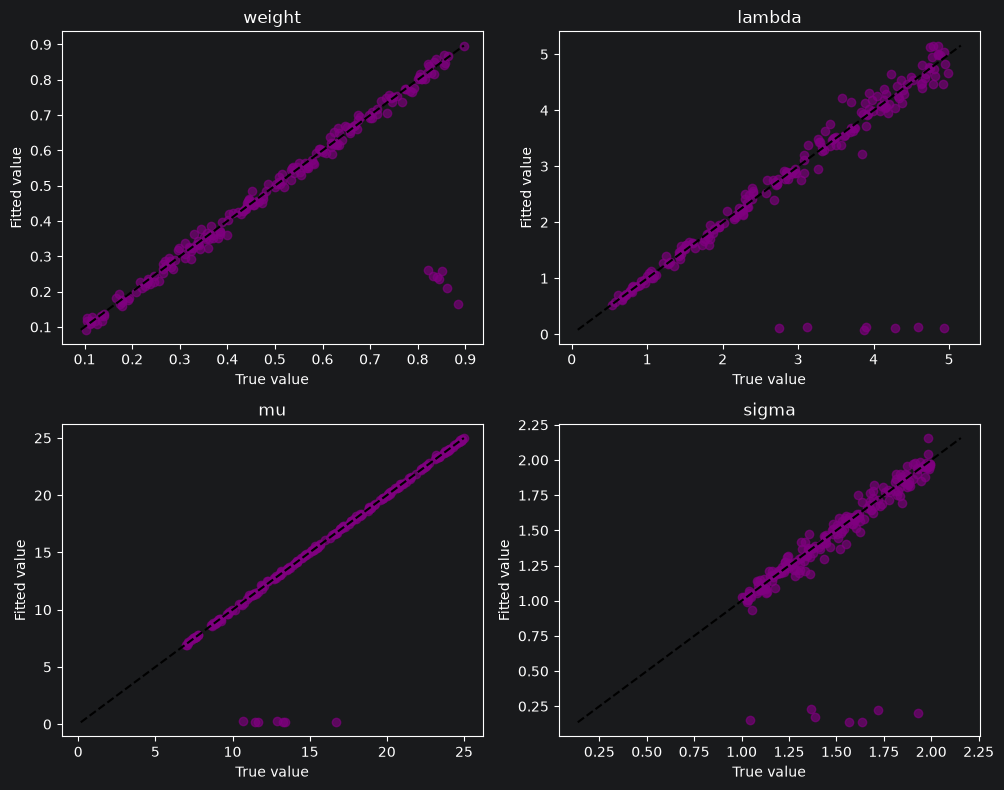

In [5]:
column_names = ["weight", "lambda", "mu", "sigma"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, column_name in zip(axes.flat, column_names):
    true_values = exp_norm_true_parameter_df[column_name]
    fitted_values = exp_norm_fitted_parameter_df[column_name]

    lower = min(true_values.min(), fitted_values.min())
    upper = max(true_values.max(), fitted_values.max())

    ax.scatter(true_values, fitted_values, color="purple", alpha=0.65)
    ax.plot([lower, upper], [lower, upper], color="black", linestyle="--")
    ax.set_xlabel("True value")
    ax.set_ylabel("Fitted value")
    ax.set_title(column_name)

plt.tight_layout()
plt.show()

## Inspect unusual fits

As a simple diagnostic, select fits where the estimated normal mean is below 1.
The plots below use the zero-based DataFrame index directly, avoiding an
off-by-one mismatch between a fit and its generated dataset.

In [6]:
unusual = exp_norm_fitted_parameter_df[
    exp_norm_fitted_parameter_df["mu"] < 1
]

print(f"Unusual fits: {len(unusual)}")
unusual

Unusual fits: 7


,weight,lambda,mu,sigma
21,0.242316,0.103925,0.179179,0.153981
31,0.260311,0.115192,0.166971,0.140107
47,0.235282,0.137015,0.265810,0.222191
85,0.258257,0.121741,0.164818,0.136103
155,0.165656,0.079767,0.227650,0.198860
168,0.211641,0.118387,0.280759,0.232942
187,0.244485,0.129148,0.206888,0.171339


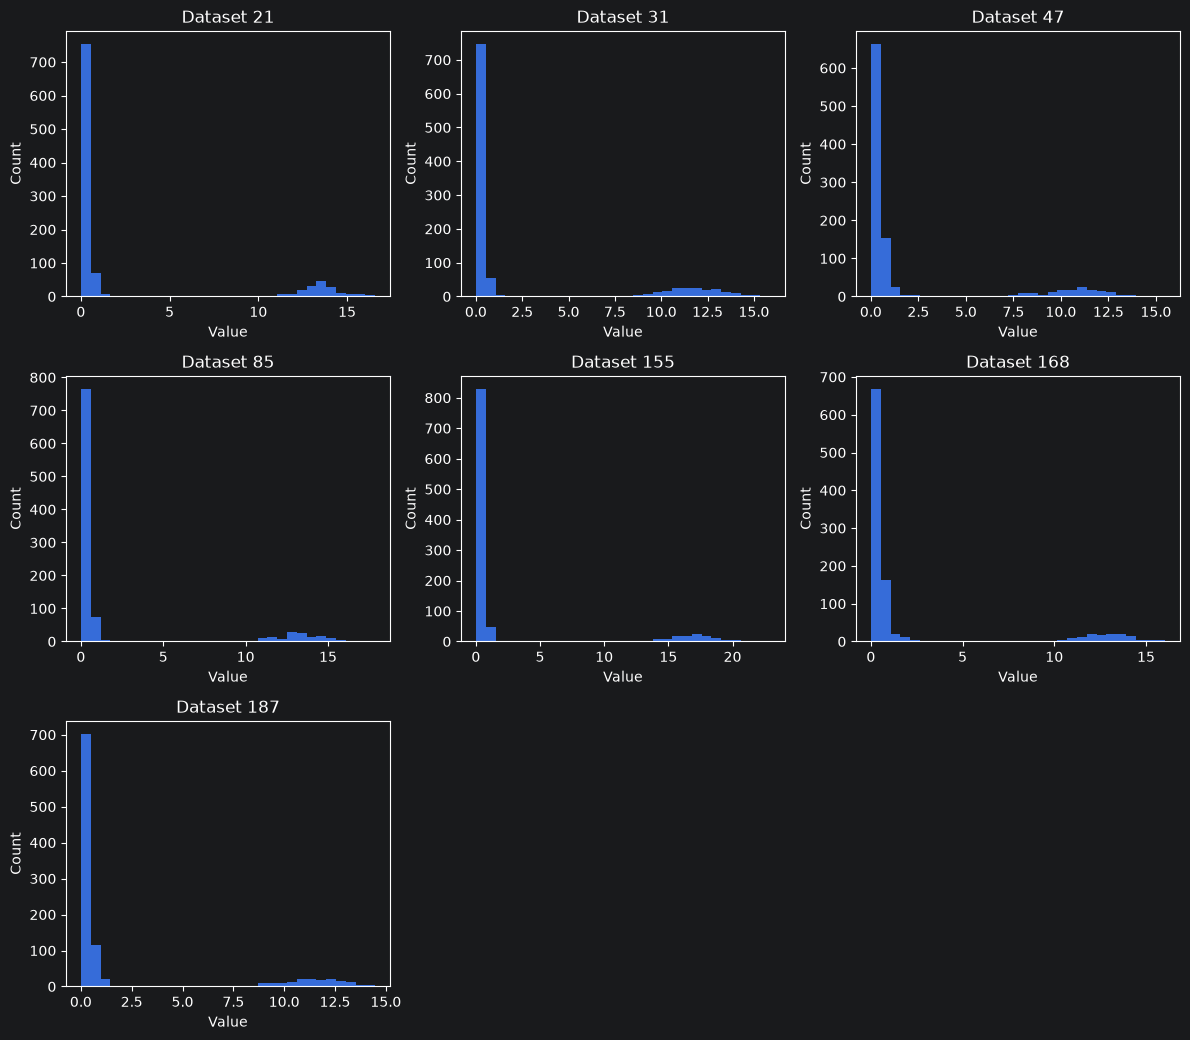

In [7]:
if unusual.empty:
    print("No unusual fits matched the diagnostic rule.")
else:
    n_columns = 3
    n_rows = int(np.ceil(len(unusual) / n_columns))
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(12, 3.5 * n_rows),
        squeeze=False,
    )

    for ax, dataset_index in zip(axes.flat, unusual.index):
        ax.hist(exp_norm_simulations[dataset_index].data, bins=30)
        ax.set_title(f"Dataset {dataset_index}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")

    for ax in axes.flat[len(unusual):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

## Convergence diagnostics

Iteration counts and convergence flags are available as `.n_iter` and
`.converged` on every `ExpNormalFit` result.

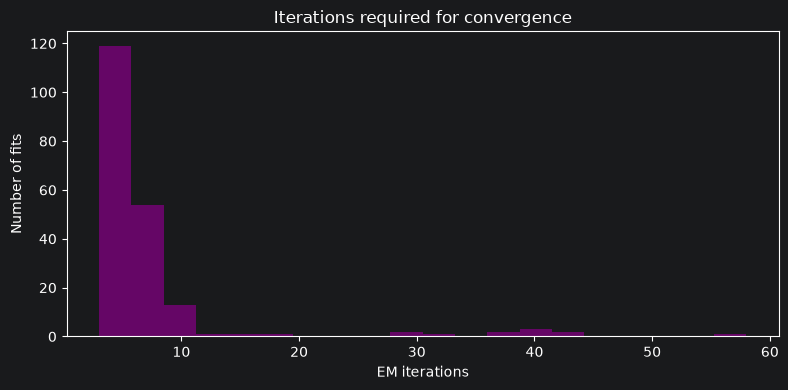

Converged fits: 100.0%
Fits completed in fewer than 10 iterations: 89.5%
Median iterations: 5


In [8]:
iteration_counts = np.array([fit.n_iter for fit in exp_norm_fits])
convergence_flags = np.array([fit.converged for fit in exp_norm_fits])

plt.figure(figsize=(8, 4))
plt.hist(iteration_counts, bins=20, color="purple", alpha=0.75)
plt.xlabel("EM iterations")
plt.ylabel("Number of fits")
plt.title("Iterations required for convergence")
plt.tight_layout()
plt.show()

proportion_below_10 = np.mean(iteration_counts < 10)

print(f"Converged fits: {convergence_flags.mean():.1%}")
print(f"Fits completed in fewer than 10 iterations: {proportion_below_10:.1%}")
print(f"Median iterations: {np.median(iteration_counts):.0f}")

The public functions hide the broad `Generator` and `Models` classes, while the
structured result objects make simulation data, fitted parameters, convergence
information, responsibilities, and likelihood history available through stable,
named attributes.